# What was that bird? Incidental learning due to playing Wingspan

Elean Huang

"What was that bird? Incidental learning due to playing Wingspan"

### Research Question
How does the board game Wingspan by Hargrave (2019) drive incidental learning?

### Methodology Overview
This notebook investigates whether playing the board game Wingspan correlates with increased Wikipedia searches for the North American birds featured in the base game. To isolate the "incidental learning" effect from real-world environmental triggers, this analysis controls for real-world bird sightings using eBird data.

Analyses:
1. Primary Analysis: A fixed-effects panel regression mapping BoardGameGeek (BGG) play logs to Wikipedia page views, controlling for eBird sightings and seasonality.

2. Secondary Analysis: A network analysis mapping the hyperlink connections between these specific birds on Wikipedia to understand their shared ecological contexts.

3. Robustness Check: Running the primary model on a control group of 10 birds not featured in Wingspan.

## 1. Setup and Library Imports
Loading the required libraries

In [1]:
import json
import os
import random
import sys

import matplotlib.pyplot as plt
import networkx as nx
import networkx.algorithms.community as nxcom
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan

START_DATE = "20260222"
END_DATE = "20260323"
SEED = 42

random.seed(SEED)

## 2. Data Collection

The defined timeframe is based on the constraints provided by the eBird API, which limit retrieved information to a maximum of 30 days. This means data is gathered from 2026-02-22 until 2026-03-23. 

The data is gathered using the scripts as can be found in the imports below. For brevity sake and because time is running out, not every module is modularised. the eBird and BGG API require an API KEY. This is stored in the os respectively under `EBIRD_API_KEY` and `BGG_API_KEY`. The eBird API key is automatically provided upon making an account. The BGG API key is provided after manual request evaluation by the BGG team.

In [2]:
# append directory of parallel module (..) to path
sys.path.append(os.path.abspath(".."))
from libraries import retrieve_ebird_data, retrieve_wikipedia_pageviews, find_bird_links

## 3. Data Preprocessing & Merging
The right-skewed distribution of the Wikipedia page views is normalised using a log transformation: `log(x+1)`. This ensures the model compares a bird's views relative to its own average, rather than comparing niche birds directly to highly popular ones.

Additionally, the BGG play dataset is lagged by one day `t-1`. This accounts for players who log their games in the evening and conduct searches the following day. Weekends are also accounted for due to more time being available for playing games.

In [3]:
def load_data(verbose=False):
    """Load the data which was collected using the imported modules"""
    datasets = {
        "bgg": pd.read_json("../data/processed/wingspan_plays_bgg.json", orient="index"),
        "bird_links": pd.read_csv("../data/processed/wikipedia_bird_links_with_counts.csv"),
        "ebird": pd.read_csv("../data/processed/wingspan_ebird_observations.csv"),
    }

    # give bgg df a header name for the column
    datasets["bgg"].columns = ["plays"]

    # the wikipedia bird views need to be processed seperately 
    # because pandas refuses to read the dates without automatically processing them
    # option convert_dates=False is ignored 
    with open("../data/processed/bird_views_wikipedia.json", "r") as f:
        datasets["wiki_views"] = pd.DataFrame.from_dict(json.load(f))

    # process it to allow it for merging with the other dataframes
    # the original provided data contains trialing 00s
    datasets["wiki_views"].index = pd.to_datetime(
        datasets["wiki_views"].index.astype(str).str[:8], 
        format="%Y%m%d"
        )
    datasets["wiki_views"].index.name = "date"

    # reshape to long format
    datasets["wiki_views_long"] = datasets["wiki_views"].reset_index().melt(
        id_vars="date", 
        var_name="bird", 
        value_name="wiki_view_count"
    )

    # the ebird data needs to be aggregated to daily counts 
    # the date needs to be normalized to allow for merging with the other 2 datasets
    datasets["ebird"]["obsDt"] = pd.to_datetime(datasets["ebird"]["obsDt"], format="mixed").dt.normalize()

    # inspect all datasets
    if verbose:
        for name, dataset in datasets.items():
            print(f"Dataset: {name}")
            display(dataset.head(2))
            print("\n")

    return datasets

datasets = load_data(verbose=False)

Now the dataset needs to be merged to construct a master dataset for analysis. To start, observations from ebird need to be aggregated to single days for each bird. Afterwards, they can be joined on date.

In [4]:
def construct_master_df(df, wiki="wiki_views_long", ebird_csv_path=None):
    # load external ebird data if path is provided, otherwise use standard dictionary
    if ebird_csv_path:
        # use mixed format because one log contains no hourly data, all others do
        ebird_df = pd.read_csv(ebird_csv_path)
        ebird_df["obsDt"] = pd.to_datetime(ebird_df["obsDt"], format="mixed").dt.normalize()
    else:
        ebird_df = df["ebird"]

    # count entries per bird per day
    ebird_counts = ebird_df.groupby(["obsDt", "comName"]).size().reset_index(name="ebird_entries")

    # create t-1 lagged bgg data
    bgg_df = df["bgg"].reset_index(names="date")[["date", "plays"]]
    bgg_df["plays_lagged"] = bgg_df["plays"].shift(1)

    # join with bgg data on date
    master_df = df[wiki].merge(
        bgg_df,
        left_on="date",
        right_on="date",
        how="left"
    )

    # join with ebird data
    master_df = master_df.merge(
        ebird_counts,
        left_on="date", 
        right_on="obsDt",
        how="left"
    )

    # remove obsolete columns
    master_df = master_df.drop(columns=["obsDt", "comName"])

    # include boolean weekend marker
    # 5: saturday and 6: sunday
    master_df["is_weekend"] = master_df.date.dt.dayofweek.isin([5, 6]) 

    print(master_df["is_weekend"].value_counts())

    # log transform bird views
    # cast NAs to 0
    master_df["wiki_view_count"] = pd.to_numeric(master_df["wiki_view_count"], errors="coerce").fillna(0)
    master_df["log_wiki_view_count"] = np.log1p(master_df["wiki_view_count"])

    display(master_df.head())

    return master_df

master_df = construct_master_df(datasets)

is_weekend
False    5440
True     2890
Name: count, dtype: int64


,date,bird,wiki_view_count,plays,plays_lagged,ebird_entries,is_weekend,log_wiki_view_count
0,2026-02-22,Acorn Woodpecker,10.0,437,NaN,NaN,True,2.397895
1,2026-02-23,Acorn Woodpecker,11.0,241,437.0,NaN,False,2.484907
2,2026-02-24,Acorn Woodpecker,11.0,218,241.0,NaN,False,2.484907
3,2026-02-25,Acorn Woodpecker,26.0,206,218.0,NaN,False,3.295837
4,2026-02-26,Acorn Woodpecker,12.0,210,206.0,NaN,False,2.564949


# 3.9 Descriptive statistics

In [5]:
master_df.describe()

,date,wiki_view_count,plays,plays_lagged,ebird_entries,log_wiki_view_count
count,8330,8330.000000,8330.000000,8160.000000,5780.0,8330.000000
mean,2026-03-12 16:39:11.020408320,27.691597,267.244898,278.604167,1.0,2.391419
min,2026-02-22 00:00:00,0.000000,160.000000,160.000000,1.0,0.000000
25%,2026-03-05 00:00:00,3.000000,210.000000,210.000000,1.0,1.386294
50%,2026-03-15 00:00:00,9.000000,250.000000,254.000000,1.0,2.302585
75%,2026-03-22 00:00:00,20.000000,307.000000,335.000000,1.0,3.044522
max,2026-03-23 00:00:00,732.000000,437.000000,437.000000,1.0,6.597146
std,NaN,52.997317,74.427563,78.821003,0.0,1.320382


## 4. Primary Analysis: Fixed-Effects Panel Regression
A fixed-effects panel model is used to account for time-invariant unobserved heterogeneity (Bald Eagle vs. the American Avocet). This improves the measurement of a spike in Wingspan plays correlating with a rise in Wikipedia views relative to the given bird"s own average. The first evaluation is based on the standard `nonrobust` option, with an additional `HC3` analysis being performed afterwards. Due to there being ~5700 observations, the p value is difficult to interpret, and we turn to AIC and BIC instead for model comparison of all models.

In [6]:
def fepr_analysis(master_df, plays, diagnose=False, cov_type="nonrobust"):
    regression_vars = [
        "log_wiki_view_count", 
        "plays_lagged", 
        "ebird_entries", 
        "is_weekend", 
        "bird", 
        "date"
    ]

    # drop missing valuables because the analysis wouldn"t work otherwise
    analysis_df = master_df.dropna(subset=regression_vars).copy()

    # remove ebird entries from formula due to it being a singular entry per bird 

    # C(bird) creates the entity fixed effects 
    formula = f"log_wiki_view_count ~ {plays} + is_weekend + C(bird)"

    # fit model, clustering standard errors by bird to account for repeated measures
    model = smf.ols(formula, data=analysis_df).fit(cov_type=cov_type)

    # Print the summary
    print(model.summary())

    if diagnose:
        bp_test = het_breuschpagan(model.resid, model.model.exog)
        bp_pvalue = bp_test[1]

        print(f"Breusch-Pagan p-value: {bp_pvalue}")

fepr_analysis(master_df, "plays_lagged", diagnose=True)

                             OLS Regression Results                            
Dep. Variable:     log_wiki_view_count   R-squared:                       0.895
Model:                             OLS   Adj. R-squared:                  0.892
Method:                  Least Squares   F-statistic:                     280.9
Date:                 Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                         19:57:22   Log-Likelihood:                -3311.8
No. Observations:                 5780   AIC:                             6968.
Df Residuals:                     5608   BIC:                             8113.
Df Model:                          171                                         
Covariance Type:             nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [7]:
fepr_analysis(master_df, plays="plays_lagged", cov_type="HC3")

                             OLS Regression Results                            
Dep. Variable:     log_wiki_view_count   R-squared:                       0.895
Model:                             OLS   Adj. R-squared:                  0.892
Method:                  Least Squares   F-statistic:                     4005.
Date:                 Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                         19:57:23   Log-Likelihood:                -3311.8
No. Observations:                 5780   AIC:                             6968.
Df Residuals:                     5608   BIC:                             8113.
Df Model:                          171                                         
Covariance Type:                   HC3                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [8]:
# robustness check, switch lagged plays with plays on the same day
fepr_analysis(master_df, "plays", cov_type="HC3")

                             OLS Regression Results                            
Dep. Variable:     log_wiki_view_count   R-squared:                       0.895
Model:                             OLS   Adj. R-squared:                  0.892
Method:                  Least Squares   F-statistic:                     7075.
Date:                 Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                         19:57:23   Log-Likelihood:                -3318.4
No. Observations:                 5780   AIC:                             6981.
Df Residuals:                     5608   BIC:                             8127.
Df Model:                          171                                         
Covariance Type:                   HC3                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

### Interpretation
The main model using HC3 robust standard errors demonstrates a statistically significant positive relationship between lagged Wingspan plays and Wikipedia page views (`p < .001, b = 0.0003`). Although significant, the effect size is very small. The control variable for weekend seasonality was not statistically significant (`p = .423`).

The unlagged robustness check resulted in a non-significant coefficient (`p = .671`), which supports the causal sequence that gameplay precedes the search volume.

## Placebo Test
To ensure the observed increases in Wikipedia views are related to playing Wingspan instead of being caused by confounding factors, a placebo test is conducted. This involves using the same FEPR model but with a randomly sampled control group of 170 North American bird species present in the eBird logs but absent from the Wingspan base game.

In [9]:
def construct_alternative_df():
    full_ebird_observations = pd.read_csv("../data/raw/ebird_observations_2026_03_27.csv")
    wingspan_bird_list = set(
        pd.read_excel("../data/raw/Wingspan Bird List ENG-NED-DEU.xlsx")["ScientificName"]
        )

    return full_ebird_observations[~full_ebird_observations["sciName"].isin(wingspan_bird_list)]

alternative_df = construct_alternative_df()

This list of alternative birds can then be used to construct a dataset of birds not in the board game. To make the comparison fair, the same number of birds will be randomly sampled from the constructed list, and their page views retrieved on Wikipedia.

In [17]:
def retrieve_alternative_bird_views(df, samples=170):
    """Retrieve the 170 placebo bird viewcounts and save to file"""

    unique_df = df.drop_duplicates(subset=["sciName"])
    sample_df = unique_df.sample(n=samples, random_state=SEED)
    final_df = sample_df.rename(columns={
        "sciName": "ScientificName",
        "comName": "EnglishName"}
        )

    # provide with header again
    fetcher = retrieve_wikipedia_pageviews.WikipediaPageviewRetriever(
        "WingspanIncidentalLearning (13411438@uva.nl)"
        )
    
    bird_views = fetcher.process_bird_list(final_df, START_DATE, END_DATE, ["en", "fr", "es"])
    fetcher.save_to_json(bird_views, "../data/processed/placebo_bird_views_wikipedia.json")

# uncomment to run
retrieve_alternative_bird_views(alternative_df)

  0%|          | 0/170 [00:00<?, ?it/s]

  4%|▎         | 6/170 [00:11<05:09,  1.89s/it]

Request error for Vireo nelsoni: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/fr.wikipedia/all-access/user/Vireo%20nelsoni/daily/20260222/20260323


  7%|▋         | 12/170 [00:22<04:53,  1.86s/it]

Request error for Anser rossii x Branta hutchinsii: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Anser%20rossii%20x%20Branta%20hutchinsii/daily/20260222/20260323
Request error for Anser rossii x Branta hutchinsii: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/fr.wikipedia/all-access/user/Anser%20rossii%20x%20Branta%20hutchinsii/daily/20260222/20260323
Request error for Anser rossii x Branta hutchinsii: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/es.wikipedia/all-access/user/Anser%20rossii%20x%20Branta%20hutchinsii/daily/20260222/20260323


...

 98%|█████████▊| 166/170 [05:10<00:07,  1.86s/it]

Request error for Tyrannus verticalis x forficatus: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Tyrannus%20verticalis%20x%20forficatus/daily/20260222/20260323
Request error for Tyrannus verticalis x forficatus: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/fr.wikipedia/all-access/user/Tyrannus%20verticalis%20x%20forficatus/daily/20260222/20260323
Request error for Tyrannus verticalis x forficatus: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/es.wikipedia/all-access/user/Tyrannus%20verticalis%20x%20forficatus/daily/20260222/20260323


 99%|█████████▉| 168/170 [05:14<00:03,  1.88s/it]

Request error for Pipilo maculatus x ocai: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Pipilo%20maculatus%20x%20ocai/daily/20260222/20260323
Request error for Pipilo maculatus x ocai: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/fr.wikipedia/all-access/user/Pipilo%20maculatus%20x%20ocai/daily/20260222/20260323
Request error for Pipilo maculatus x ocai: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/es.wikipedia/all-access/user/Pipilo%20maculatus%20x%20ocai/daily/20260222/20260323


100%|██████████| 170/170 [05:17<00:00,  1.87s/it]


With this new placebo bird list, an alternative master df can be constructed, now with placebo birds and their observations which can be placed in the FPER model.

In [18]:
def load_placebo(df):
    """Update the dataframe dictionary with the new placebo bird dataset"""
    with open("../data/processed/placebo_bird_views_wikipedia.json", "r") as f:
        temp = pd.DataFrame.from_dict(json.load(f))

    # process it to allow it for merging with the other dataframes
    # the original provided data contains trialing 00s
    temp.index = pd.to_datetime(temp.index.astype(str).str[:8], format="%Y%m%d")
    temp.index.name = "date"

    # reshape to long format
    df["wiki_views_placebo"] = temp.reset_index().melt(
        id_vars="date", 
        var_name="bird", 
        value_name="wiki_view_count"
    )

    return df

placebo_df = construct_master_df(
    load_placebo(datasets), 
    wiki="wiki_views_placebo", 
    ebird_csv_path="../data/raw/ebird_observations_2026_03_27.csv"
    )

is_weekend
False    35870
True     24820
Name: count, dtype: int64


,date,bird,wiki_view_count,plays,plays_lagged,ebird_entries,is_weekend,log_wiki_view_count
0,2026-02-22,Canyon Wren,1.0,437,NaN,NaN,True,0.693147
1,2026-02-23,Canyon Wren,1.0,241,437.0,NaN,False,0.693147
2,2026-02-24,Canyon Wren,1.0,218,241.0,NaN,False,0.693147
3,2026-02-25,Canyon Wren,1.0,206,218.0,NaN,False,0.693147
4,2026-02-26,Canyon Wren,11.0,210,206.0,1.0,False,2.484907


In [19]:
# descriptives of the placebo list
placebo_df.describe()

,date,wiki_view_count,plays,plays_lagged,ebird_entries,log_wiki_view_count
count,60690,60690.000000,60690.000000,60520.000000,60010.000000,60690.000000
mean,2026-03-15 12:14:07.058823424,9.982831,271.044818,272.721910,1.002833,1.316131
min,2026-02-22 00:00:00,0.000000,160.000000,160.000000,1.000000,0.000000
25%,2026-03-11 00:00:00,0.000000,211.000000,210.000000,1.000000,0.000000
50%,2026-03-18 00:00:00,2.000000,250.000000,254.000000,1.000000,1.098612
75%,2026-03-22 00:00:00,6.000000,335.000000,335.000000,1.000000,1.945910
max,2026-03-23 00:00:00,492.000000,437.000000,437.000000,2.000000,6.200509
std,NaN,36.169687,75.171336,76.994862,0.053150,1.190935


In [13]:
# perform the FEPR analysis using the alternative birds
fepr_analysis(placebo_df, plays="plays_lagged + ebird_entries", cov_type="HC3")

                             OLS Regression Results                            
Dep. Variable:     log_wiki_view_count   R-squared:                       0.845
Model:                             OLS   Adj. R-squared:                  0.845
Method:                  Least Squares   F-statistic:                 1.380e+04
Date:                 Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                         19:57:26   Log-Likelihood:                -39639.
No. Observations:                60010   AIC:                         7.962e+04
Df Residuals:                    59837   BIC:                         8.118e+04
Df Model:                          172                                         
Covariance Type:                   HC3                                         
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

### Placebo result interpretation
The placebo test also found a significant positive relationship between lagged game plays and Wikipedia views for the non-featured birds (`p < .001, b = 0.0005`). Because this test is significant and has a higher `b` than the original model, it suggests that the observed variance is driven by omitted factors rather than through playing Wingspan.

# 5. Network analysis 

Nodes: 132
Edges: 241


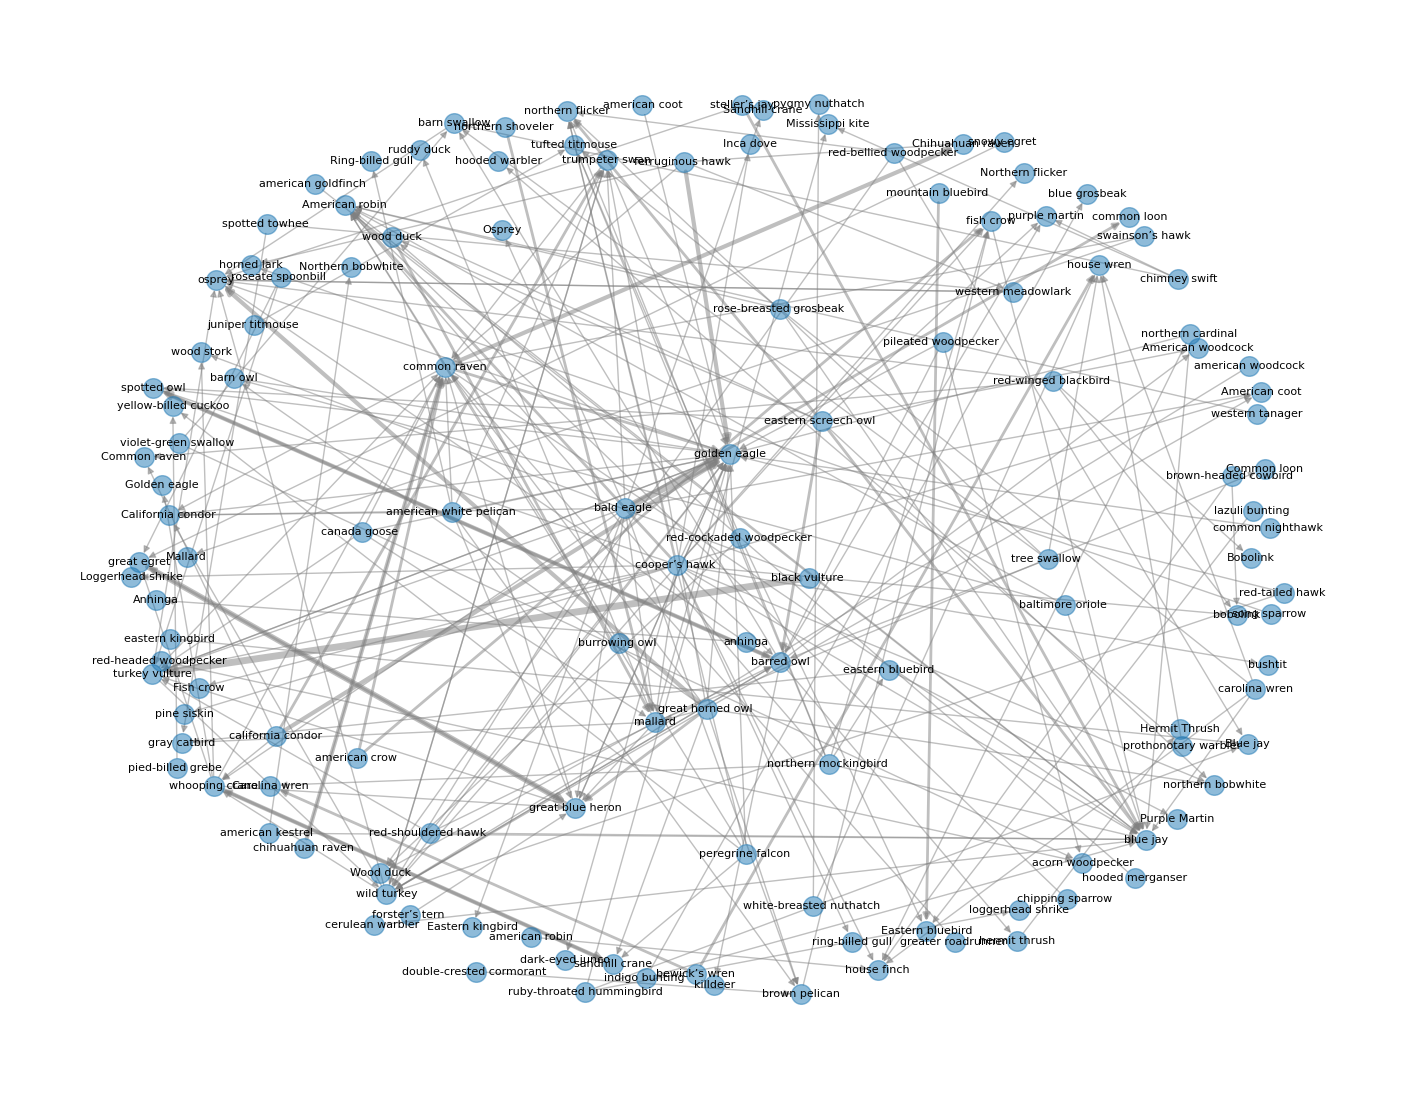

In [20]:
def create_network(bird_links):
    G = nx.DiGraph()

    # add edges with weights
    for index, row in bird_links.iterrows():
        G.add_edge(row["source_bird"], row["target_bird"], weight=row["count"])

    # create edge width using their count
    edge_widths = [G[u][v]["weight"] for u, v in G.edges()]

    # 18 birds do not link to any birds at all
    print("Nodes:", G.number_of_nodes()) 
    print("Edges:", G.number_of_edges()) 

    # layout uses the edge weights to pull frequently linked birds closer together
    pos = nx.spring_layout(G, k=1.2, weight="weight", seed=SEED) 

    fig, ax = plt.subplots(figsize=(18, 14))

    nx.draw_networkx(
        G,
        pos=pos,
        ax=ax,
        node_size=200,
        edge_color="grey",
        width=edge_widths,
        alpha=0.5, 
        with_labels=False,
        arrows=True,
        arrowsize=10,
    )

    bird_labels = {n: n for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=bird_labels, font_size=8, ax=ax) 

    ax.axis("off")
    plt.show()

    return G

# first ensure that capitalisation is not an issue
datasets["bird_links"]["source_bird"] = datasets["bird_links"]["source_bird"].apply(lambda x: x.lower())

G = create_network(datasets["bird_links"])

### Network Analysis Results
The network graph consists of 132 nodes and 241 edges, meaning 38 Wingspan birds have no Wikipedia connections to others in the game. Birds frequently link to central hubs like the Golden Eagle and Cooper's Hawk, but rarely to each other, resulting in a sparse map.

Top Birds by Degree Centrality:
 - golden eagle: 0.198
 - cooper’s hawk : 0.168
 - common raven: 0.130
 - blue jay: 0.122
 - wild turkey: 0.107

Average Clustering Coefficient: 0.084

Number of communities: 8
 Community 1: ['chihuahuan raven', 'american crow ', 'Chihuahuan raven', 'common raven', 'Mallard', 'fish crow', 'swainson’s hawk', 'greater roadrunner ']
 Community 2: ['american kestrel ', 'carolina wren', 'Purple Martin', 'american goldfinch ', 'eastern bluebird', 'cerulean warbler ', 'steller’s jay', 'chipping sparrow ', 'barn owl', 'baltimore oriole ', 'indigo bunting ', 'juniper titmouse ', 'blue jay', 'blue grosbeak', 'northern mockingbird ', 'burrowing owl ', 'Northern bobwhite', 'western tanager', 'tufted titmouse', 'rose-breasted grosbeak ', 'American robin']
 Community 3: ['bald eagle ', 'common nighthawk ', 'Sandhill crane', 'american coot', 'california condor', 'Anhinga', 'California condor', 'Ring-billed gull', 'brown pelican', 'Eastern kingbird', 'song sparrow ', 'r

<Figure size 1600x1200 with 0 Axes>

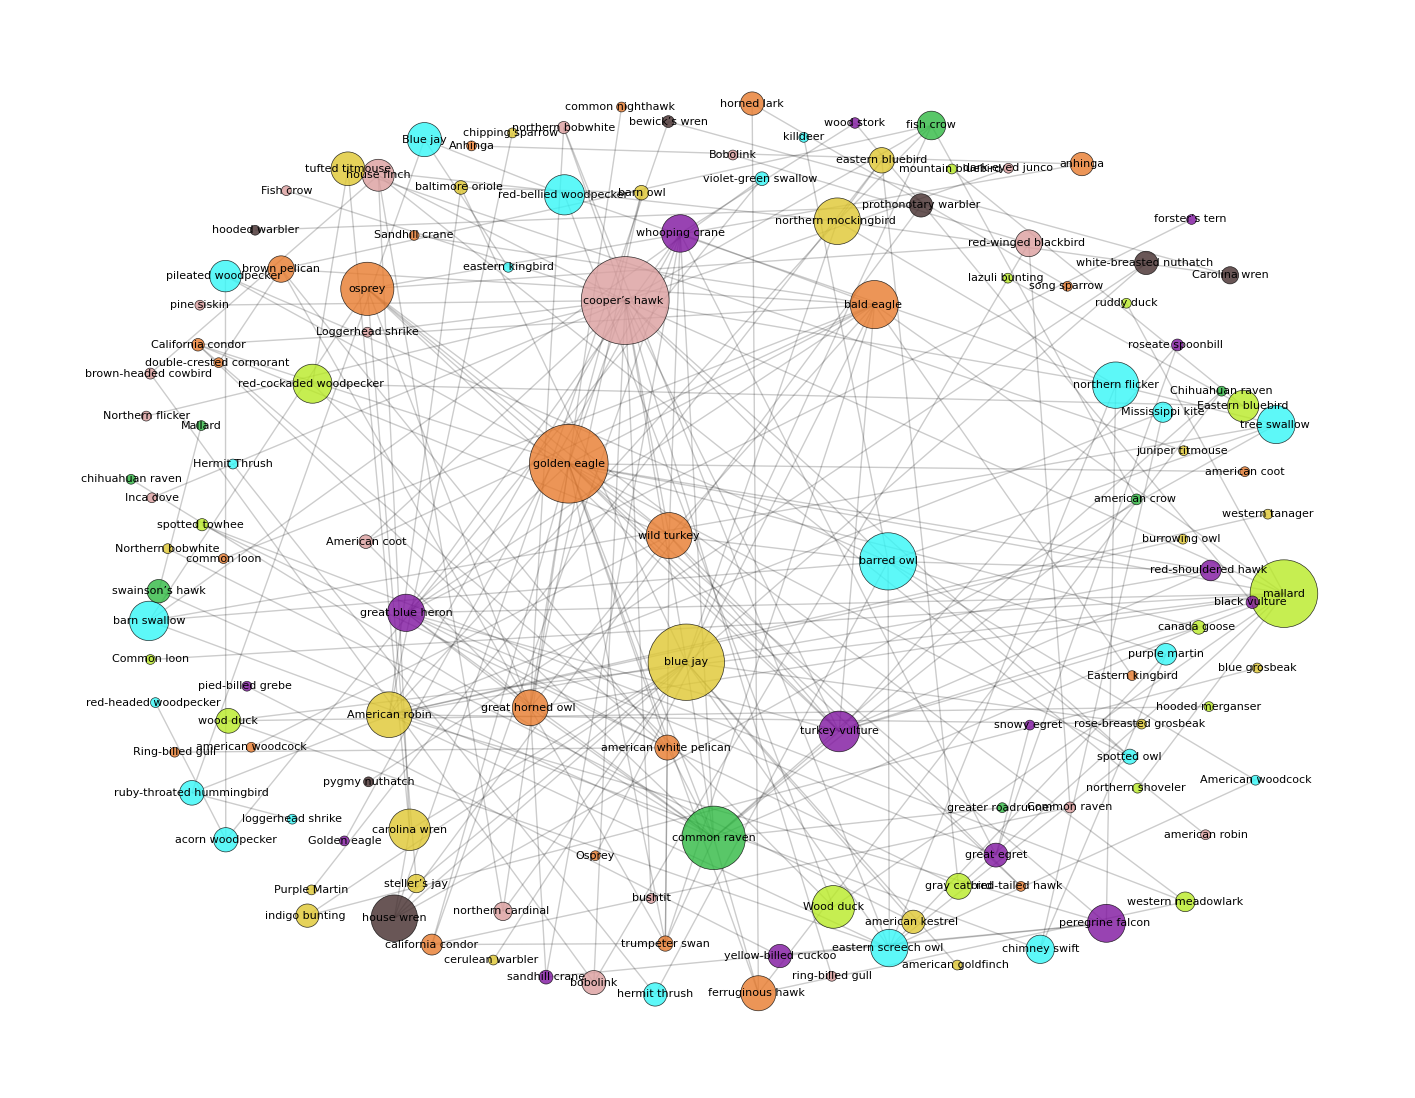

In [21]:
def create_louvain_community(G):
    # compute and print metrics
    degree_centrality = nx.degree_centrality(G)
    print("Top Birds by Degree Centrality:")
    top_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
    for bird, cent in top_centrality:
        print(f" - {bird}: {cent:.3f}")

    G_undirected = G.to_undirected()
    clustering_coeff = nx.average_clustering(G_undirected)
    print(f"\nAverage Clustering Coefficient: {clustering_coeff:.3f}")
    
    # community detection louvain
    communities = nxcom.louvain_communities(G_undirected, seed=42)
    print(f"\nNumber of communities: {len(communities)}")
    for i, community in enumerate(communities):
        print(f" Community {i+1}: {list(community)}")

    # visualization Setup
    # map every bird node to its community
    node_to_community = {}
    for i, community in enumerate(communities):
        for node in community:
            node_to_community[node] = i

    community_colors = [
        "#2fb942", "#dfc731", "#e87b2d", "#7f149f", 
        "#35f7f7", "#432C2C", "#b8ea25", "#db9e9e", 
        "#0D8181", "#c7b8d1", "#a96e2a", "#e9e4b1", 
        "#a0e5b5", "#111179", "#BC6363",
    ]

    node_colors_full = []
    for node in G_undirected.nodes():
        community_index = node_to_community.get(node, 0)
        node_colors_full.append(community_colors[community_index % len(community_colors)])

    # compute betweenness centrality for node sizes
    betweenness_cent = nx.betweenness_centrality(G_undirected)
    all_betweenness = list(betweenness_cent.values())
    min_b_all = min(all_betweenness) if all_betweenness else 0
    max_b_all = max(all_betweenness) if all_betweenness else 1

    denominator = (max_b_all - min_b_all) if (max_b_all - min_b_all) > 0 else 1

    node_sizes_full = []
    for node in G_undirected.nodes():
        b = betweenness_cent.get(node, 0)
        size = 50 + 3950 * (b - min_b_all) / denominator
        node_sizes_full.append(size)

    # Plot the graph
    plt.figure(figsize=(16, 12))
    pos = nx.spring_layout(G_undirected, k=0.9, iterations=20)

    fig, ax = plt.subplots(figsize=(18, 14))

    nx.draw_networkx_nodes(
        G_undirected, pos, 
        node_color=node_colors_full, 
        node_size=node_sizes_full, 
        alpha=0.8,
        edgecolors="black", 
        linewidths=0.5
    )

    bird_labels = {n: n for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=bird_labels, font_size=8, ax=ax) 
    nx.draw_networkx_edges(G_undirected, pos, alpha=0.2)

    plt.axis("off")
    plt.show()

create_louvain_community(G)

### Louvain community results
The Louvain community detection algorithm divided the network into 8 communities. For example, Community 1 consists predominantly of corvids, Community 3 contains waterbirds and raptors, and Community 5 groups woodpeckers with owls and swallows.

## Conclusion
While the main model showed a positive relationship, the significant results of the placebo test unfortunately make inferring causality not possible. The effect sizes found were very small, and it is likely that unobserved confounding factors are a better explanation for the recorded page views. 